# V2 — Sample équilibré + Neural Network

1. Création d'un sample équilibré (30%, classes 50/50)
2. Feature engineering
3. Neural Network pour prédire le signe du retour

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cpu


---
## Part 1 — Création du sample équilibré (30%)

In [2]:
X_full = pd.read_csv('Data/X_train.csv')
y_full = pd.read_csv('Data/y_train.csv')

print(f'X_train complet : {X_full.shape}')
print(f'y_train complet : {y_full.shape}')

y_full['target_SIGN'] = (y_full['target'] > 0).astype(int)
print(f'\nDistribution originale :')
print(y_full['target_SIGN'].value_counts())
print(f'Proportion Up : {y_full["target_SIGN"].mean()*100:.1f}%')

X_train complet : (527073, 45)
y_train complet : (527073, 2)

Distribution originale :
target_SIGN
1    267323
0    259750
Name: count, dtype: int64
Proportion Up : 50.7%


In [3]:
total_n = len(y_full)
sample_n = int(total_n * 0.30)
n_per_class = sample_n // 2

idx_up = y_full[y_full['target_SIGN'] == 1].index.values
idx_down = y_full[y_full['target_SIGN'] == 0].index.values

sampled_up = np.random.choice(idx_up, size=n_per_class, replace=False)
sampled_down = np.random.choice(idx_down, size=n_per_class, replace=False)

sampled_idx = np.concatenate([sampled_up, sampled_down])
np.random.shuffle(sampled_idx)

X_sample = X_full.loc[sampled_idx].reset_index(drop=True)
y_sample = y_full.loc[sampled_idx, ['ROW_ID', 'target']].reset_index(drop=True)

print(f'Sample : {X_sample.shape[0]:,} lignes (50/50 équilibré)')

Sample : 158,120 lignes (50/50 équilibré)


In [4]:
X_sample.to_csv('Data/X_train_sample.csv', index=False)
y_sample.to_csv('Data/y_train_sample.csv', index=False)
print('✅ X_train_sample.csv et y_train_sample.csv sauvegardés')

✅ X_train_sample.csv et y_train_sample.csv sauvegardés


---
## Part 2 — Feature Engineering

In [5]:
df = X_sample.merge(y_sample, on='ROW_ID')

ret_cols = [f'RET_{i}' for i in range(1, 21)]

# Interaction
df['RET_1_TURNOVER'] = df['RET_1'] * df['MEDIAN_DAILY_TURNOVER']

# Rolling statistics
df['RET_MEAN_5'] = df[[f'RET_{i}' for i in range(1, 6)]].mean(axis=1)
df['RET_MEAN_20'] = df[ret_cols].mean(axis=1)
df['RET_STD_5'] = df[[f'RET_{i}' for i in range(1, 6)]].std(axis=1)
df['RET_STD_20'] = df[ret_cols].std(axis=1)

# Cumulative return
df['RET_CUM_5'] = df[[f'RET_{i}' for i in range(1, 6)]].sum(axis=1)
df['RET_CUM_20'] = df[ret_cols].sum(axis=1)

# Momentum indicators
df['RET_POSITIVE_COUNT_5'] = (df[[f'RET_{i}' for i in range(1, 6)]] > 0).sum(axis=1)
df['RET_POSITIVE_COUNT_20'] = (df[ret_cols] > 0).sum(axis=1)

# Recent vs old
df['RET_RECENT_VS_OLD'] = df['RET_MEAN_5'] - df[[f'RET_{i}' for i in range(16, 21)]].mean(axis=1)

# Target
df['target_SIGN'] = (df['target'] > 0).astype(int)

print(f'Dataset avec FE : {df.shape}')

Dataset avec FE : (158120, 57)


---
## Part 3 — Préparation pour le Neural Network

In [6]:
exclude_cols = ['ROW_ID', 'TS', 'ALLOCATION', 'target', 'target_SIGN']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].fillna(0).copy()
y = df['target_SIGN'].values

# Normalisation par groupe
numeric_cols = [c for c in feature_cols if c != 'GROUP']
for grp in X['GROUP'].unique():
    mask = X['GROUP'] == grp
    scaler = StandardScaler()
    X.loc[mask, numeric_cols] = scaler.fit_transform(X.loc[mask, numeric_cols])

X = X.values.astype(np.float32)
y = y.astype(np.float32)

# Split 80/20
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Features : {X_train.shape[1]}')
print(f'Train    : {X_train.shape[0]:,}')
print(f'Val      : {X_val.shape[0]:,}')

Features : 52
Train    : 126,496
Val      : 31,624


In [7]:
# Créer les DataLoaders PyTorch
BATCH_SIZE = 512

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Train batches : 248
Val batches   : 62


---
## Part 4 — Architecture du Neural Network

Réseau petit et très régularisé :
- 3 couches cachées (128 → 64 → 32)
- BatchNorm + Dropout (0.4) à chaque couche
- Sortie sigmoïde (classification binaire)

In [8]:
class ReturnSignNet(nn.Module):
    def __init__(self, input_dim, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            # Couche 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Couche 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Couche 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),  # moins de dropout à la fin
            
            # Sortie
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x).squeeze(-1)

input_dim = X_train.shape[1]
model = ReturnSignNet(input_dim).to(device)
print(model)
print(f'\nParamètres : {sum(p.numel() for p in model.parameters()):,}')

ReturnSignNet(
  (net): Sequential(
    (0): Linear(in_features=52, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Paramètres : 17,601


---
## Part 5 — Entraînement avec Early Stopping

In [11]:
# Hyperparamètres
EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 10  # early stopping

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
# Historique
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0
best_epoch = 0
patience_counter = 0

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    train_losses, train_preds, train_targets = [], [], []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        y_hat = model(X_batch)
        loss = criterion(y_hat, y_batch)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        train_preds.extend((y_hat > 0.5).cpu().numpy())
        train_targets.extend(y_batch.cpu().numpy())
    
    train_loss = np.mean(train_losses)
    train_acc = accuracy_score(train_targets, train_preds)
    
    # --- VALIDATION ---
    model.eval()
    val_losses, val_preds, val_targets = [], [], []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_hat = model(X_batch)
            loss = criterion(y_hat, y_batch)
            
            val_losses.append(loss.item())
            val_preds.extend((y_hat > 0.5).cpu().numpy())
            val_targets.extend(y_batch.cpu().numpy())
    
    val_loss = np.mean(val_losses)
    val_acc = accuracy_score(val_targets, val_preds)
    
    scheduler.step(val_loss)
    
    # Historique
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), 'best_nn_model.pt')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} {"★" if patience_counter == 0 else ""}')
    
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}. Best epoch: {best_epoch+1}')
        break

print(f'\n✅ Best validation accuracy : {best_val_acc:.4f} (epoch {best_epoch+1})')

Epoch   1 | Train Loss: 0.6980 Acc: 0.5061 | Val Loss: 0.6925 Acc: 0.5162 ★
Epoch   2 | Train Loss: 0.6932 Acc: 0.5115 | Val Loss: 0.6919 Acc: 0.5177 ★
Epoch   3 | Train Loss: 0.6924 Acc: 0.5162 | Val Loss: 0.6915 Acc: 0.5204 ★
Epoch   4 | Train Loss: 0.6918 Acc: 0.5204 | Val Loss: 0.6911 Acc: 0.5259 ★
Epoch   5 | Train Loss: 0.6916 Acc: 0.5225 | Val Loss: 0.6912 Acc: 0.5251 
Epoch   6 | Train Loss: 0.6913 Acc: 0.5236 | Val Loss: 0.6909 Acc: 0.5287 ★
Epoch  10 | Train Loss: 0.6903 Acc: 0.5292 | Val Loss: 0.6908 Acc: 0.5254 
Epoch  14 | Train Loss: 0.6898 Acc: 0.5323 | Val Loss: 0.6904 Acc: 0.5288 ★
Epoch  15 | Train Loss: 0.6896 Acc: 0.5337 | Val Loss: 0.6904 Acc: 0.5242 
Epoch  18 | Train Loss: 0.6888 Acc: 0.5363 | Val Loss: 0.6900 Acc: 0.5292 ★
Epoch  20 | Train Loss: 0.6884 Acc: 0.5387 | Val Loss: 0.6901 Acc: 0.5297 ★
Epoch  23 | Train Loss: 0.6876 Acc: 0.5416 | Val Loss: 0.6901 Acc: 0.5299 ★
Epoch  24 | Train Loss: 0.6872 Acc: 0.5413 | Val Loss: 0.6898 Acc: 0.5304 ★
Epoch  25 | Tra

---
## Part 6 — Courbes d'entraînement

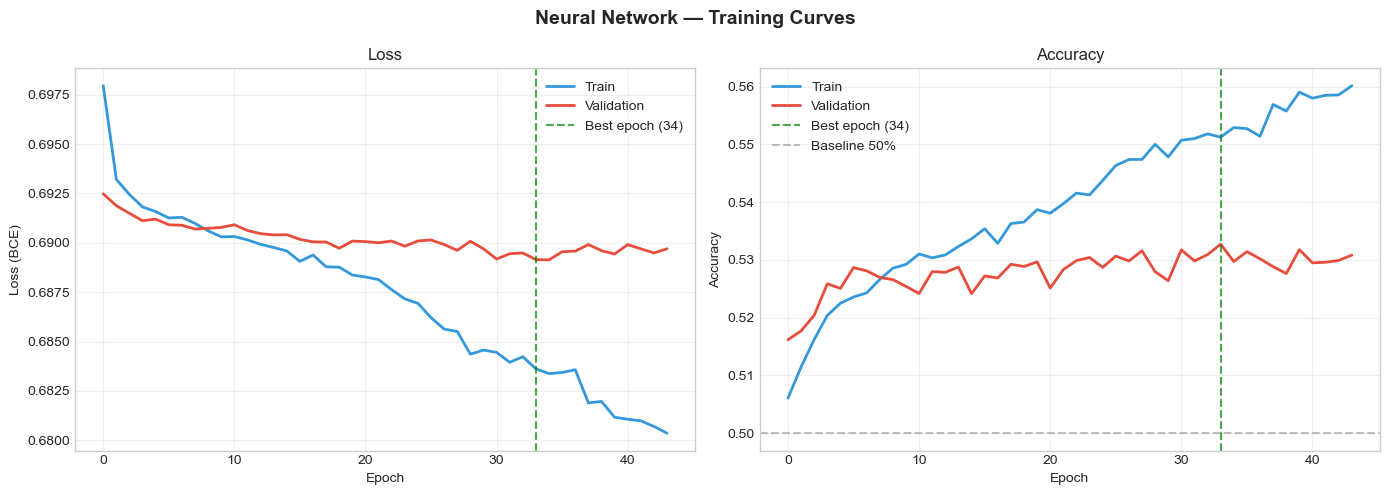

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', color='#3498db', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', color='#e74c3c', linewidth=2)
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch+1})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', color='#3498db', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation', color='#e74c3c', linewidth=2)
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch+1})')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline 50%')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Neural Network — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7 — Évaluation finale

=== Classification Report ===
              precision    recall  f1-score   support

    Down (0)       0.53      0.55      0.54     15812
      Up (1)       0.53      0.51      0.52     15812

    accuracy                           0.53     31624
   macro avg       0.53      0.53      0.53     31624
weighted avg       0.53      0.53      0.53     31624

Validation Accuracy : 0.5327


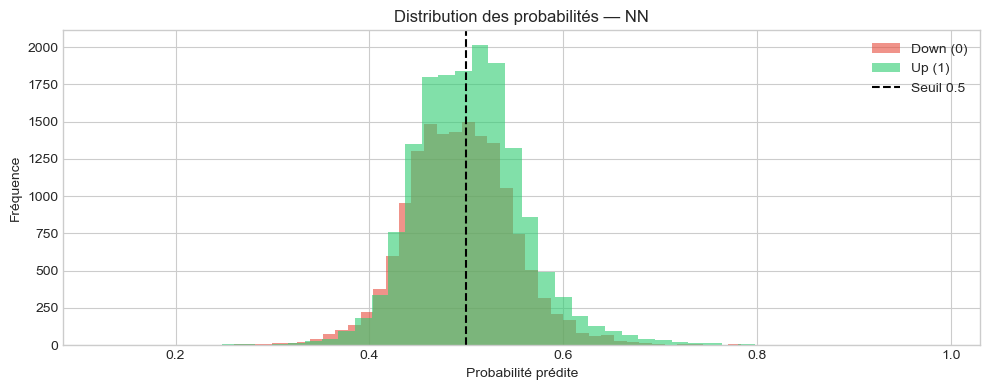

In [13]:
# Charger le meilleur modèle
model.load_state_dict(torch.load('best_nn_model.pt'))
model.eval()

# Prédictions sur tout le validation set
with torch.no_grad():
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_proba = model(X_val_t).cpu().numpy()
    y_pred = (y_proba > 0.5).astype(int)

print('=== Classification Report ===')
print(classification_report(y_val, y_pred, target_names=['Down (0)', 'Up (1)']))

val_acc = accuracy_score(y_val, y_pred)
print(f'Validation Accuracy : {val_acc:.4f}')

# Distribution des probabilités
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_proba[y_val == 0], bins=50, alpha=0.6, label='Down (0)', color='#e74c3c')
ax.hist(y_proba[y_val == 1], bins=50, alpha=0.6, label='Up (1)', color='#2ecc71')
ax.axvline(0.5, color='black', linestyle='--', label='Seuil 0.5')
ax.set_xlabel('Probabilité prédite')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des probabilités — NN')
ax.legend()
plt.tight_layout()
plt.show()

# === Part 8 — Random Forest + LightGBM Comparison ===


=== Random Forest ===
  Best CV: 0.5378 | Val Acc: 0.5422
  Params: {'n_estimators': 100, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': 15}

=== LightGBM ===


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

  Best CV: 0.5317 | Val Acc: 0.5319
  Params: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}

=== COMPARAISON ===


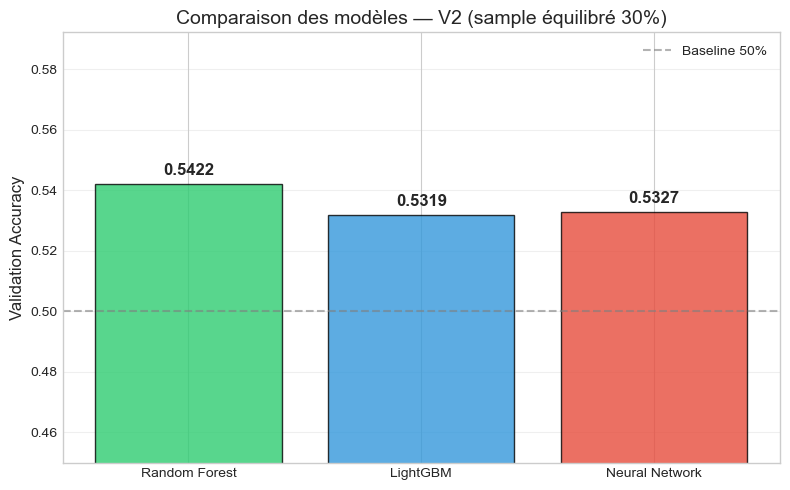

  Random Forest        → 0.5422
  Neural Network       → 0.5327
  LightGBM             → 0.5319


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

results_compare = {}

# --- Random Forest (rapide) ---
print('=== Random Forest ===')
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators': [100],
     'max_depth': [5, 10, 15],
     'min_samples_split': [5, 10],
     'max_features': ['sqrt', 'log2']},
    n_iter=15, cv=3, scoring='accuracy', random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf_val_acc = accuracy_score(y_val, rf_search.predict(X_val))
results_compare['Random Forest'] = rf_val_acc
print(f'  Best CV: {rf_search.best_score_:.4f} | Val Acc: {rf_val_acc:.4f}')
print(f'  Params: {rf_search.best_params_}')

# --- LightGBM (rapide) ---
print('\n=== LightGBM ===')
lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    {'n_estimators': [100],
     'max_depth': [3, 5, 7, 10],
     'learning_rate': [0.05, 0.1, 0.2]},
    n_iter=20, cv=3, scoring='accuracy', random_state=42, n_jobs=-1
)
lgb_search.fit(X_train, y_train)
lgb_val_acc = accuracy_score(y_val, lgb_search.predict(X_val))
results_compare['LightGBM'] = lgb_val_acc
print(f'  Best CV: {lgb_search.best_score_:.4f} | Val Acc: {lgb_val_acc:.4f}')
print(f'  Params: {lgb_search.best_params_}')

# --- Neural Network (déjà calculé) ---
results_compare['Neural Network'] = best_val_acc

# === Graphique comparatif ===
print('\n=== COMPARAISON ===')
fig, ax = plt.subplots(figsize=(8, 5))
models = list(results_compare.keys())
accs = list(results_compare.values())
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(models, accs, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Baseline 50%')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', fontweight='bold', fontsize=12)

ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Comparaison des modèles — V2 (sample équilibré 30%)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.45, max(accs) + 0.05)
plt.tight_layout()
plt.savefig('model_comparison_V2.png', dpi=150, bbox_inches='tight')
plt.show()

for m, a in sorted(results_compare.items(), key=lambda x: -x[1]):
    print(f'  {m:20s} → {a:.4f}')